## Preprocessing NKI Rockland ET Data 

In [1]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import cv2
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

from scipy.ndimage import gaussian_filter
from pathlib import Path

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## *The Present* DS1 Preprocesssing

In [ ]:
present_df1 = pd.read_csv("present_df_all_raw.csv")
print(present_df1.head())
present_df1 = present_df1.iloc[:, 1:]
print(present_df1.head())

# Sort by subjectID and time 
present_df1 = present_df1.sort_values(['subjectID', 'times'])
print(present_df1.head(-20))

### Descriptive Stats 

Summary stats for column: x_corr_pixels
mean     653.117197
min    -3160.400000
max     3147.400000
std       82.660693
Name: x_corr_pixels, dtype: float64
Summary stats for column: y_corr_pixels
mean     410.297653
min    -3263.300000
max     3275.800000
std      127.219302
Name: y_corr_pixels, dtype: float64
Summary stats for column: left_eye_pupil_mm
mean      3.453293
min       0.000000
max     111.250000
std       1.221416
Name: left_eye_pupil_mm, dtype: float64
Summary stats for column: right_eye_pupil_mm
mean      3.436943
min       0.000000
max     118.770000
std       1.217789
Name: right_eye_pupil_mm, dtype: float64
missing values x_corr: 0
missing values y_corr: 0
missing values left_eye_pupil: 0
missing values right_eye_pupil: 0


Text(0.5, 1.0, 'right_eye_pupil_mm histogram')

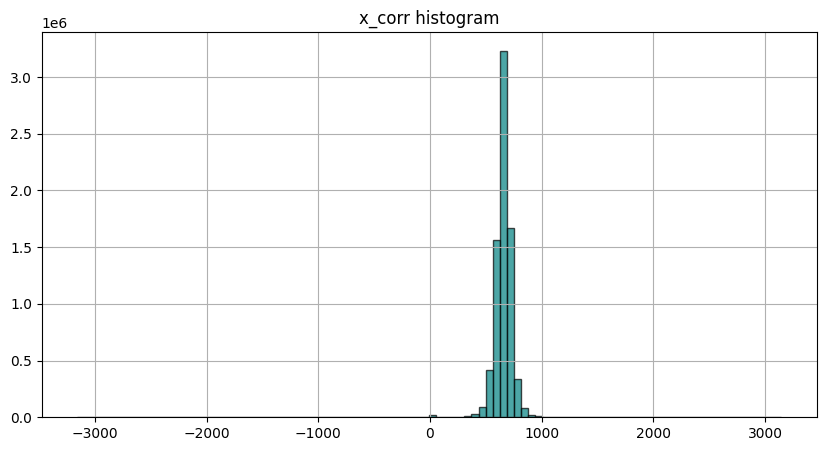

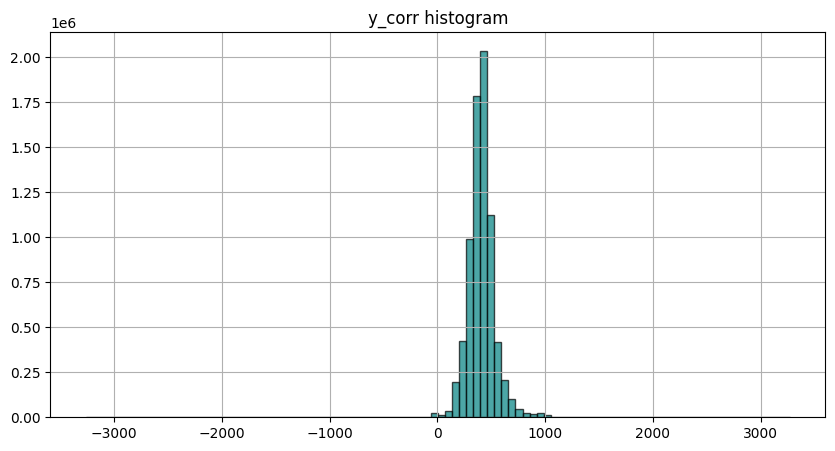

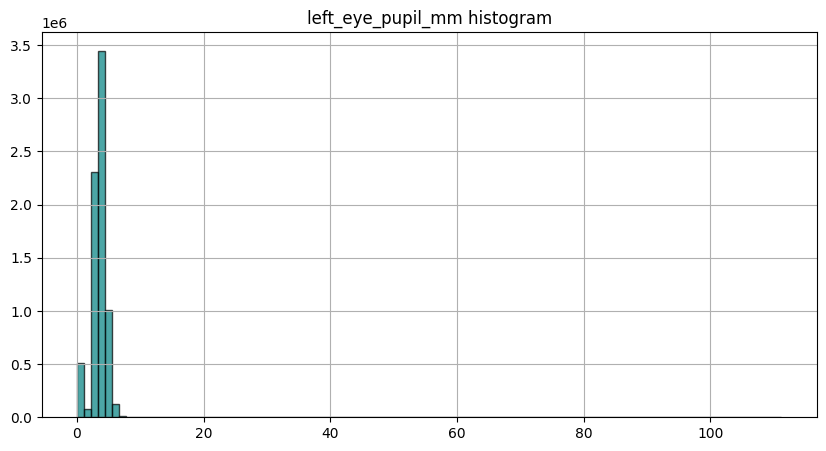

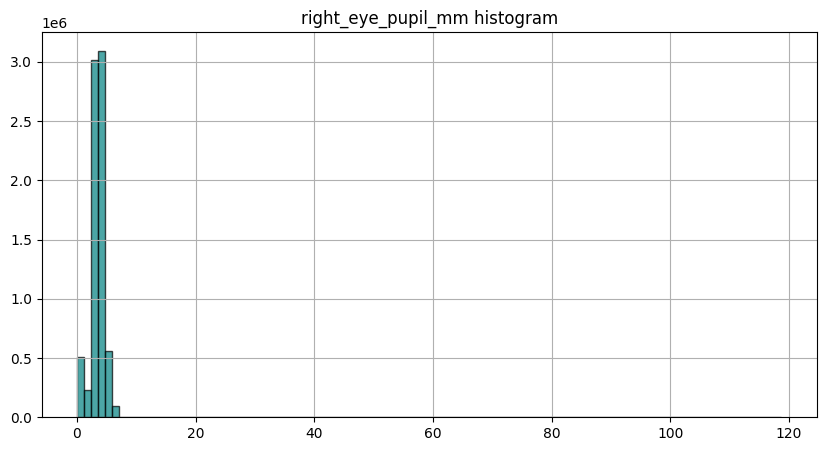

In [11]:
descr_stats(present_df1, 'x_corr_pixels')
descr_stats(present_df1, 'y_corr_pixels')
descr_stats(present_df1, 'left_eye_pupil_mm')
descr_stats(present_df1, 'right_eye_pupil_mm')

# check missing values 
print("missing values x_corr:", present_df1['x_corr_pixels'].isna().sum()) 
print("missing values y_corr:", present_df1['y_corr_pixels'].isna().sum())
print("missing values left_eye_pupil:", present_df1['left_eye_pupil_mm'].isna().sum())
print("missing values right_eye_pupil:", present_df1['right_eye_pupil_mm'].isna().sum())

# plot histograms 
plt.figure(figsize=(10, 5))
present_df1["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df1["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
present_df1["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
present_df1["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 1. Clean Data: clip to screen dimension for x_corr and y_corr and recode extreme values of pupil diameter to 0 


#### 1a: Clip x_corr and y_corr to the screen dimensions 

Values outside the dimension of our screen get recoded to their the lower or upper bound

Summary stats for column: x_corr_pixels
mean     653.247680
min        0.000000
max     1920.000000
std       80.364717
Name: x_corr_pixels, dtype: float64
Summary stats for column: y_corr_pixels
mean     410.329761
min        0.000000
max     1080.000000
std      123.582833
Name: y_corr_pixels, dtype: float64


Text(0.5, 1.0, 'y_corr histogram')

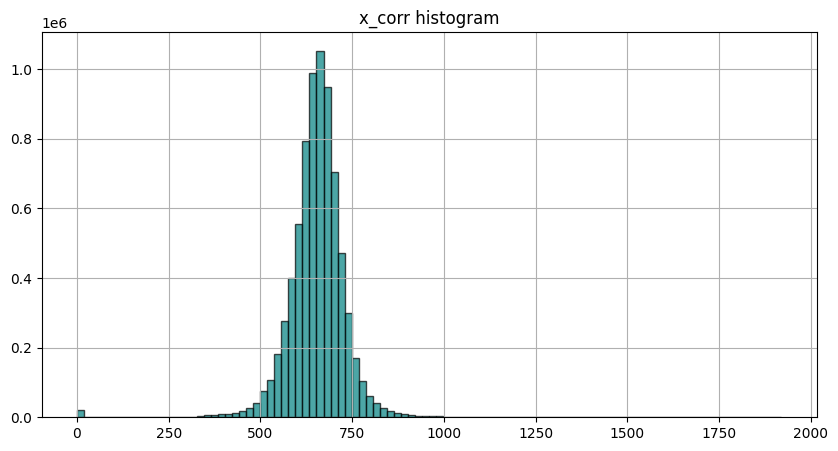

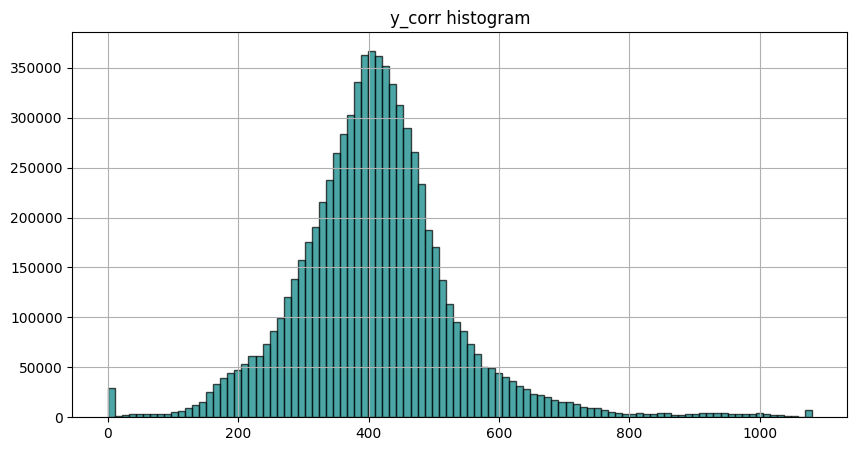

In [13]:
present_df1_filtered = present_df1.copy()

SCREEN_W = 1920
SCREEN_H = 1080

present_df1_filtered["x_corr_pixels"] = present_df1["x_corr_pixels"].clip(0, SCREEN_W)
present_df1_filtered["y_corr_pixels"] = present_df1["y_corr_pixels"].clip(0, SCREEN_H)

# Look at data again 
descr_stats(present_df1_filtered, 'x_corr_pixels')
descr_stats(present_df1_filtered, 'y_corr_pixels')

# plot histograms 
plt.figure(figsize=(10, 5))
present_df1_filtered["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df1_filtered["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

#### 1b: Recode extreme values of pupil diameter to 0
To run the blink detection algothrim, it needs 0 values, not NA. 


Summary stats for column: left_eye_pupil_mm
mean    3.448654
min     0.000000
max     9.000000
std     1.209498
Name: left_eye_pupil_mm, dtype: float64
Summary stats for column: right_eye_pupil_mm
mean    3.433412
min     0.000000
max     9.000000
std     1.210149
Name: right_eye_pupil_mm, dtype: float64


Text(0.5, 1.0, 'right_eye_pupil_mm histogram')

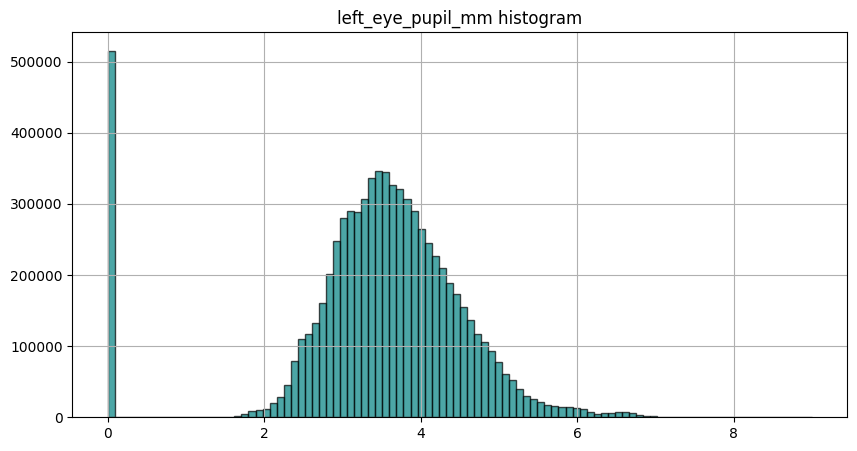

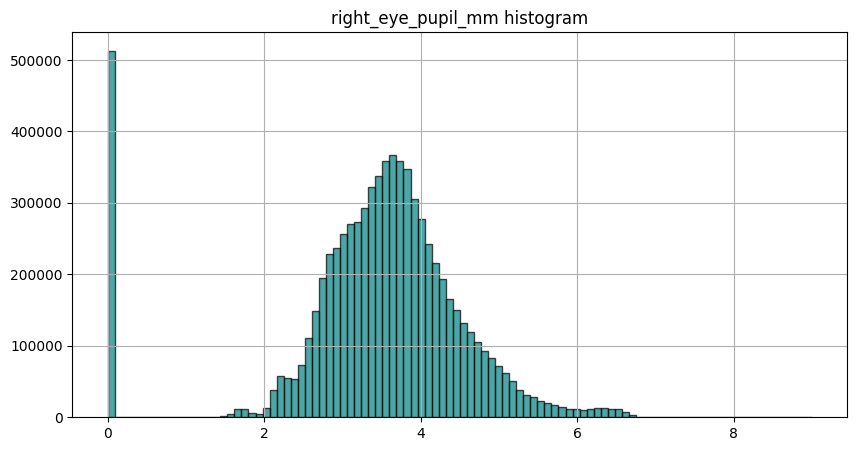

In [14]:
# largest possible pupil value 
max_pupil_diameter = 9

# filter out data 
present_df1_filtered['left_eye_pupil_mm'] = present_df1_filtered["left_eye_pupil_mm"].where(
    present_df1_filtered['left_eye_pupil_mm'] <= max_pupil_diameter, 0
)
present_df1_filtered['right_eye_pupil_mm'] = present_df1_filtered["right_eye_pupil_mm"].where(
    present_df1_filtered['right_eye_pupil_mm'] <= max_pupil_diameter, 0
)

# re-check data 
descr_stats(present_df1_filtered, 'left_eye_pupil_mm')
descr_stats(present_df1_filtered, 'right_eye_pupil_mm')
plt.figure(figsize=(10, 5))
present_df1_filtered["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
present_df1_filtered["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 2. Blink Detection - Hershman et al. 2018

Using open source code from Hershman et al. 2018: https://osf.io/jyz43/files/qh5sg

In [ ]:
def diff(series):
	"""
	Python implementation of matlab's diff function
	"""
	return series[1:] - series[:-1]

def smooth(x, window_len):
	"""
	Python implementation of matlab's smooth function
	"""

	if window_len < 3:
		return x

	# Window length must be odd
	if window_len%2 == 0:
		window_len += 1

	w = np.ones(window_len)
	y = np.convolve(w, x, mode='valid') / len(w)
	y = np.hstack((x[:window_len//2], y, x[len(x)-window_len//2:]))

	for i in range(0, window_len//2):
		y[i] = np.sum(y[0 : i+i]) / ((2*i) + 1)

	for i in range(len(x)-window_len//2, len(x)):
		y[i] = np.sum(y[i - (len(x) - i - 1) : i + (len(x) - i - 1)]) / ((2*(len(x) - i - 1)) + 1)

	return y

def based_noise_blinks_detection(pupil_size, sampling_freq):
	"""
	Function to find blinks and return blink onset and offset indices
	Adapted from: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

	Input:
		pupil_size          : [numpy array/list] of pupil size data for left/right eye
		sampling_freq       : [float] sampling frequency of eye tracking hardware (default = 1000 Hz)
		concat              : [boolean] concatenate close blinks/missing trials or not. See R. Hershman et. al. for more information
		concat_gap_interval : [float] interval between successive missing samples/blinks to concatenate
	Output:
		blinks              : [dictionary] {"blink_onset", "blink_offset"} containing numpy array/list of blink onset and offset indices
	"""
	sampling_interval = 1000 // sampling_freq
	concat_gap_interval = 100

	blink_onset = []
	blink_offset = []
	blinks = {"blink_onset": blink_onset, "blink_offset": blink_offset}

	pupil_size = np.asarray(pupil_size)
	missing_data = np.array(pupil_size == 0, dtype="float32")
	difference = diff(missing_data)

	blink_onset = np.where(difference == 1)[0]
	blink_offset = np.where(difference == -1)[0] + 1

	length_blinks = len(blink_offset) + len(blink_onset)


	# Edge Case 1: there are no blinks
	if (length_blinks == 0):
		return blinks


	# Edge Case 2: the data starts with a blink. In this case, blink onset will be defined as the first missing value.
	"""
		Two possible situations may cause this:
			i.  starts with a blink but does not end with a blink ---> len(blink_onset) < len(blink_offset)
			ii. starts with a blink and ends with a blink		  ---> len(blink_onset) == len(blink_offset) and (blink_onset[0] == blink_offset[0])
	"""
	if ((len(blink_onset) < len(blink_offset)) or ((len(blink_onset) == len(blink_offset)) and (blink_onset[0] > blink_offset[0]))) and pupil_size[0] == 0:
		blink_onset = np.hstack((0, blink_onset))


	# Edge Case 3: the data ends with a blink. In this case, blink offset will be defined as the last missing sample
	"""
		Two possible situations may cause this:
			i.  ends with a blink but does not start with a blink ---> len(blink_offset) < len(blink_onset)
			ii. ends with a blink and starts with a blink		  ---> Already handled "start with blink" in Edge case 2 so it reduces to i (previous case)
	"""
	if (len(blink_offset) < len(blink_onset)) and pupil_size[-1] == 0:
		blink_offset = np.hstack((blink_offset, len(pupil_size) - 1))

	# Smoothing the data in order to increase the difference between the measurement noise and the eyelid signal.
	ms_4_smoothing = 10
	samples2smooth = ms_4_smoothing // sampling_interval
	smooth_pupil_size = np.array(smooth(pupil_size, samples2smooth), dtype='float32')

	smooth_pupil_size[np.where(smooth_pupil_size == 0)[0]] = float('nan')
	smooth_pupil_size_diff = diff(smooth_pupil_size)

	"""
	Finding values <=0 and >=0 in order to find monotonically increasing and decreasing sections of smoothened pupil data

			Eg. a =     [2, 1, 2, 8, 7, 6, 5, 4, 4, 0, 0, 0, 0, 0, 3, 3, 3, 8, 9, 10, 2, 3, 10]
	                              ----------------  S           E  =================
			diff(a)=   [-1  1  6 -1 -1 -1 -1  0 -4  0  0  0  0  3  0  0  5  1  1  -8  1  7]

	monotonically_dec = [T  F  F  T  T  T  T  T  T  T  T  T  T  F  T  T  F  F  F   T  F  F]   (T=True, F=False)
	monotonically_dec = [F  T  T  F  F  F  F  T  F  T  T  T  T  T  T  T  T  T  T   F  T  T]

	---> The monotonically decreasing sequence before the blink is underlined with -- and the monotonically increasing sequence after the blink with ==
	---> S : denotes the initially detected onset of blink
	---> E : denotes the initially detected offset of blink

	>> Looking at diff(a), all values in the montonically decreasing sequence should be <= 0 and those included in the monotonically increasing sequence >= 0
	>> Hence, by moving left from the initially detected onset while T(True) values are encountered in monotonically_dec we can update the onset to the start of monotonically_dec seq
	>> By moving right from the initially detected offset while T(True) values are encountered in monotonically_inc we can update the offset to the end of monotonically_inc seq + 1
	"""
	monotonically_dec = smooth_pupil_size_diff <= 0
	monotonically_inc = smooth_pupil_size_diff >= 0

	# Finding correct blink onsets and offsets using monotonically increasing and decreasing arrays
	for i in range(len(blink_onset)):
		# Edge Case 2: If data starts with blink we do not update it and let starting blink index be 0
		if blink_onset[i] != 0:
			j = blink_onset[i] - 1
			while j > 0 and monotonically_dec[j] == True:
				j -= 1
			blink_onset[i] = j + 1

		# Edge Case 3: If data ends with blink we do not update it and let ending blink index be the last index of the data
		if blink_offset[i] != len(pupil_size) - 1:
			j = blink_offset[i]
			while j < len(monotonically_inc) and monotonically_inc[j] == True:
				j += 1
			blink_offset[i] = j

	# Removing duplications (in case of consecutive sets): [a, b, b, c] => [a, c] or if inter blink interval is less than concat_gap_interval
	c = np.empty((len(blink_onset) + len(blink_offset),), dtype=blink_onset.dtype)
	c[0::2] = blink_onset
	c[1::2] = blink_offset
	c = list(c)

	i = 1
	while i<len(c)-1:
		if c[i+1] - c[i] <= concat_gap_interval:
			c[i:i+2] = []
		else:
			i += 2

	temp = np.reshape(c, (-1, 2), order='C')

	"""
	Multplied by sampling interval in order to give onset and offset in real time (milliseconds) by factoring in sampling rate of device used
	'+ sampling_interval' because the output should be in real time and as python indexing starts at 0 instead of 1, this is the standardising factor
	NOTE:edit the lines below to only temp[:, 0] and temp[:, 1] in case you are interested in the indices of blinks and not realtime values
	"""
	blinks["blink_onset"] = (temp[:, 0] * sampling_interval) + sampling_interval
	blinks["blink_offset"] = (temp[:, 1] * sampling_interval) + sampling_interval

	return blinks

Confirm sampling rate 

In [ ]:
# Calculate time difference between consecutive samples 
present_df1_filtered['time_diff'] = present_df1_filtered.groupby('subjectID')['times'].diff()

# Calculate sampling rate (Hz)
present_df1_filtered['sampling_rate'] = 1 / present_df1_filtered['time_diff']

descr_stats(present_df1_filtered, 'sampling_rate')

Detect blinks

In [ ]:
sampling_freq = 180
blinks = based_noise_blinks_detection(present_df1_filtered['right_eye_pupil_mm'], sampling_freq)
print(blinks)